Total valid points: 595


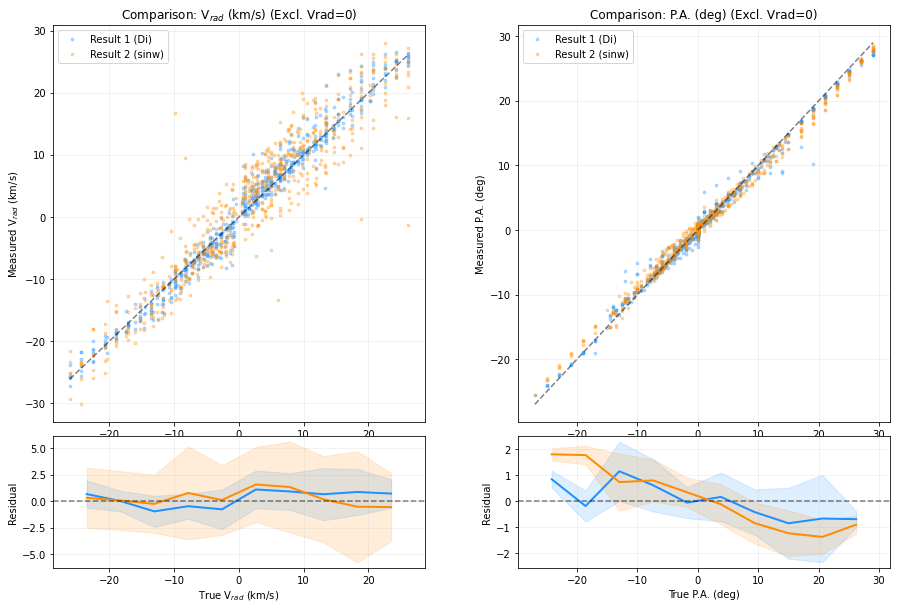

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径配置
# ==========================================
# 真值：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/01_ring...
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
# Result 1：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/output/01/rings_final2.txt
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/output/"
# Result 2：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200.../second_step_check_sinw/rings_final2.txt
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. 正则匹配 (沿用你的代码)
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def load_data():
    all_dfs = []
    # 搜索真值文件
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        
        # 构建 Result 1 路径 (ID 目录)
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        
        # 构建 Result 2 路径 (去掉 ID 前缀的文件夹名)
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t  = pd.read_csv(tf_path, delimiter=r"\s+")
                df_r1 = pd.read_csv(r1_path, delimiter=r"\s+")
                df_r2 = pd.read_csv(r2_path, delimiter=r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                })
                
                # --- 关键过滤：排除真值为 0 的点 ---
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                
                if not combined.empty:
                    all_dfs.append(combined)
            except Exception as e:
                print(f"Error loading {fid}: {e}")
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. 绘图 (双结果对比模式)
# ==========================================
def bin_stats(x, y, nbins=10):
    res = y - x
    # 动态计算范围，避免 0 值干扰
    bin_edges = np.linspace(x.min(), x.max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    
    means, stds = [], []
    for i in range(nbins):
        mask = (idx == i)
        if mask.any():
            means.append(res[mask].mean())
            stds.append(res[mask].std())
        else:
            means.append(np.nan)
            stds.append(np.nan)
    return centers, np.array(means), np.array(stds)

def plot_comparison(df):
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.25)
    
    # 子图配置：(标题, 真值列, 结果1列, 结果2列, 是否PA, GridSpec索引)
    tasks = [
        ("V$_{rad}$ (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD", False, 0),
        ("P.A. (deg)",      "True_PA",   "R1_PA",   "R2_PA",   True,  1)
    ]
    
    for label, t_col, r1_col, r2_col, is_pa, col_idx in tasks:
        ax_sc = fig.add_subplot(gs[0, col_idx])
        ax_rs = fig.add_subplot(gs[1, col_idx], sharex=ax_sc)
        
        tx = df[t_col].values
        r1y = df[r1_col].values
        r2y = df[r2_col].values
        
        if is_pa: # 对 PA 进行 120 偏移处理
            tx, r1y, r2y = tx - 120, r1y - 120, r2y - 120
        
        # Scatter
        ax_sc.scatter(tx, r1y, s=8, color='dodgerblue', alpha=0.3, label='Result 1 (Di)')
        ax_sc.scatter(tx, r2y, s=8, color='darkorange', alpha=0.3, label='Result 2 (sinw)')
        
        # Stats & Residual Lines
        for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
            c, m, s = bin_stats(tx, y_data)
            ax_rs.plot(c, m, color=color, lw=2)
            ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.15)
            
        # Decoration
        lims = [tx.min(), tx.max()]
        ax_sc.plot(lims, lims, 'k--', alpha=0.5)
        ax_sc.set_ylabel(f"Measured {label}")
        ax_sc.set_title(f"Comparison: {label} (Excl. Vrad=0)")
        ax_sc.legend(loc='upper left')
        
        ax_rs.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_rs.set_ylabel("Residual")
        ax_rs.set_xlabel(f"True {label}")
        
        ax_sc.grid(True, alpha=0.2)
        ax_rs.grid(True, alpha=0.2)

    plt.savefig("vrad_pa_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid points: {len(data)}")
        plot_comparison(data)
    else:
        print("No data matched. Please check path configurations.")

Total valid points: 595


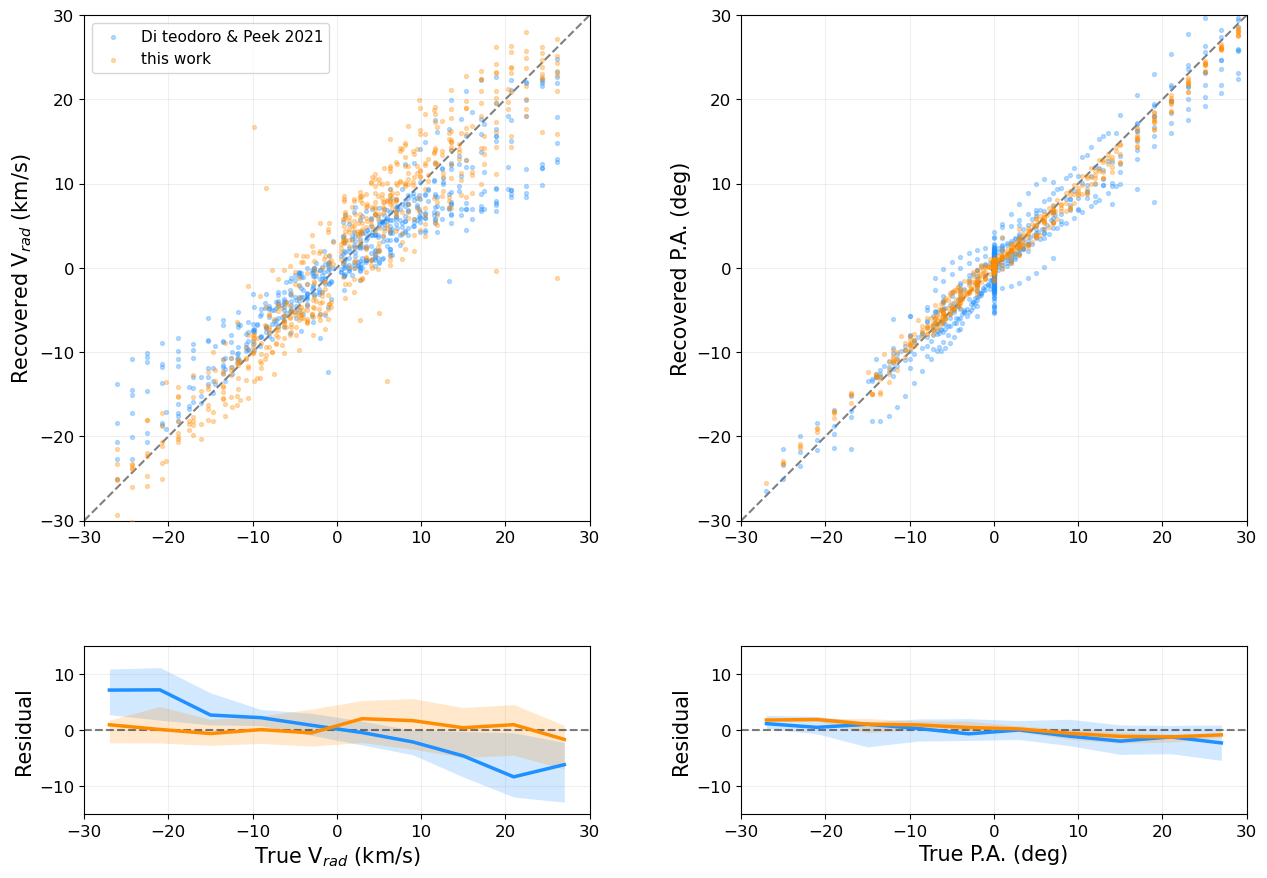

In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径配置
# ==========================================
# 真值：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/01_ring...
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
# Result 1：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/output/01/rings_final2.txt
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
# Result 2：/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/ring_v200.../second_step_check_sinw/rings_final2.txt
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. 正则匹配 (沿用你的代码)
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def load_data():
    all_dfs = []
    # 搜索真值文件
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        
        # 构建 Result 1 路径 (ID 目录)
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        
        # 构建 Result 2 路径 (去掉 ID 前缀的文件夹名)
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t  = pd.read_csv(tf_path, delimiter=r"\s+")
                df_r1 = pd.read_csv(r1_path, delimiter=r"\s+")
                df_r2 = pd.read_csv(r2_path, delimiter=r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                })
                
                # --- 关键过滤：排除真值为 0 的点 ---
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                
                if not combined.empty:
                    all_dfs.append(combined)
            except Exception as e:
                print(f"Error loading {fid}: {e}")
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. 绘图 (双结果对比模式)
# ==========================================
def plot_comparison(df):
    fig = plt.figure(figsize=(15, 12))
    # Use hspace=0.05 to keep a tiny gap or 0 for no gap
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
    
    tasks = [
        ("V$_{rad}$ (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD", False, 0),
        ("P.A. (deg)",      "True_PA",   "R1_PA",   "R2_PA",   True,  1)
    ]
    
    for label, t_col, r1_col, r2_col, is_pa, col_idx in tasks:
        ax_sc = fig.add_subplot(gs[0, col_idx])
        ax_rs = fig.add_subplot(gs[1, col_idx], sharex=ax_sc)
        
        tx = df[t_col].values
        r1y = df[r1_col].values
        r2y = df[r2_col].values
        
        if is_pa: 
            tx, r1y, r2y = tx - 120, r1y - 120, r2y - 120
        
        # 1. SCATTER PLOT
        ax_sc.scatter(tx, r1y, s=8, color='dodgerblue', alpha=0.3, label='Di teodoro & Peek 2021', zorder=2)
        ax_sc.scatter(tx, r2y, s=8, color='darkorange', alpha=0.3, label='this work', zorder=3)
        
        # 2. ASPECT RATIO LOGIC (The Fix)
        # Force the top plot area to be a perfect square
        ax_sc.set_box_aspect(1) 
        # Force the bottom plot to have the same width as the square above
        # (Height is 1/3 of the width because of height_ratios=[3,1])
        ax_rs.set_box_aspect(1/3) 

        # 3. STATS & RESIDUALS (Percentiles: 16-50-84)
        for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
            # Using updated bin_stats with percentiles (see previous response for bin_stats code)
            c, med, low, high = bin_stats_percentiles(tx, y_data) 
            ax_rs.plot(c, med, color=color, lw=2.5, zorder=5)
            ax_rs.fill_between(c, low, high, color=color, alpha=0.2, lw=0)
            
        # 4. DECORATION
        ax_sc.plot([-30, 30], [-30, 30], 'k--', alpha=0.5, zorder=1)
        ax_sc.set_ylabel(f"Recovered {label}")
        
        if not is_pa:
            ax_sc.legend(loc='upper left', frameon=True, fontsize=11)
            
        ax_rs.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_rs.set_ylabel("Residual")
        ax_rs.set_xlabel(f"True {label}")
        
        # Ensure Limits are identical for perfect 1:1 visualization
        ax_sc.set_xlim(-30, 30)
        ax_sc.set_ylim(-30, 30)
        ax_rs.set_ylim(-15, 15)
        
        ax_sc.grid(True, alpha=0.2)
        ax_rs.grid(True, alpha=0.2)

    plt.savefig("vrad_pa_comparison.pdf", bbox_inches='tight')
    plt.show()

# Utility function for the percentiles
def bin_stats_percentiles(x, y, nbins=10):
    res = y - x
    bin_edges = np.linspace(-30, 30, nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    medians, p16, p84 = [], [], []
    for i in range(nbins):
        mask = (idx == i)
        if mask.any():
            medians.append(np.nanpercentile(res[mask], 50))
            p16.append(np.nanpercentile(res[mask], 16))
            p84.append(np.nanpercentile(res[mask], 84))
        else:
            medians.extend([np.nan]*3)
    return centers, np.array(medians), np.array(p16), np.array(p84)

if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid points: {len(data)}")
        plot_comparison(data)
    else:
        print("No data matched. Please check path configurations.")

Total valid data points: 595


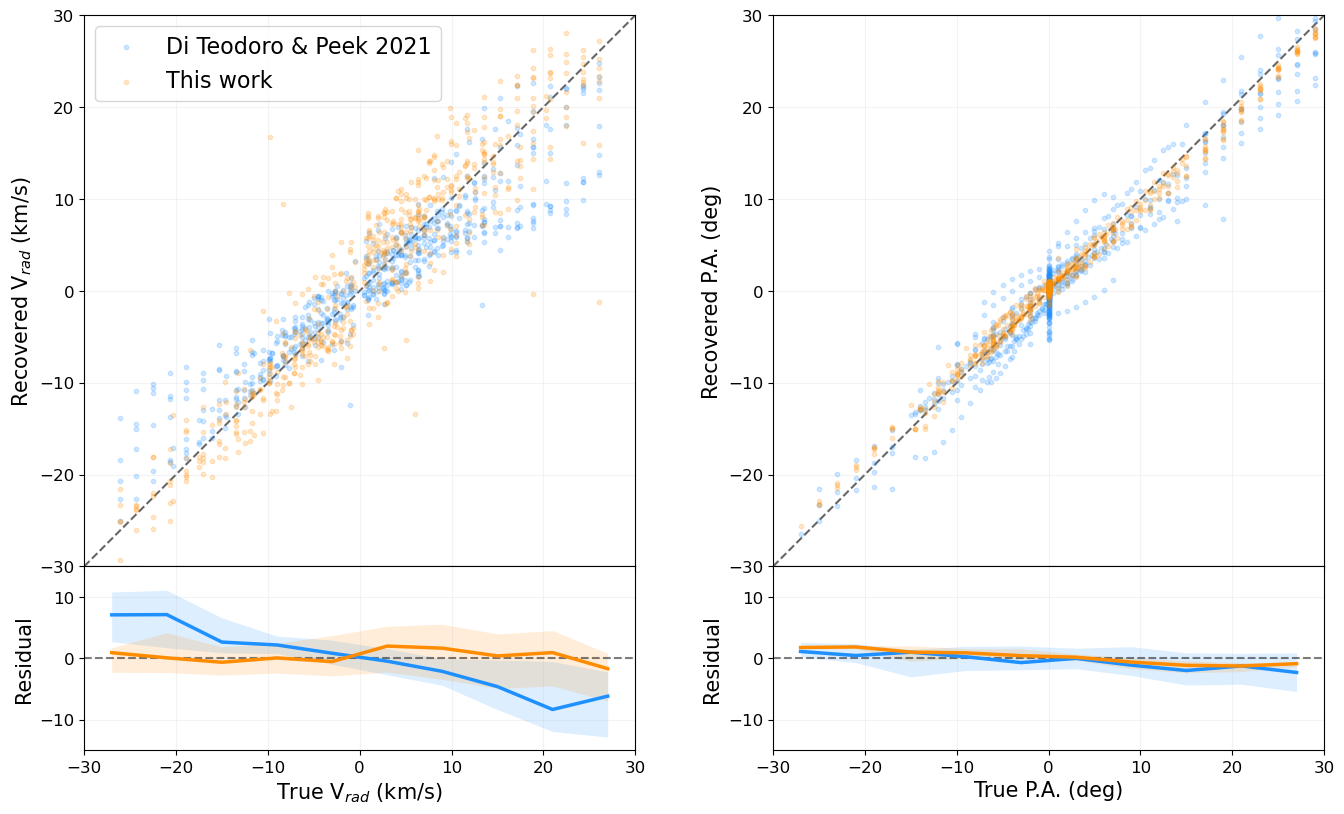

In [19]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. Path Configuration
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. Regex & Plot Settings
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ==========================================
# 3. Data Loading Logic
# ==========================================
def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t  = pd.read_csv(tf_path, delimiter=r"\s+")
                df_r1 = pd.read_csv(r1_path, delimiter=r"\s+")
                df_r2 = pd.read_csv(r2_path, delimiter=r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                })
                
                # Exclude points where True VRAD is 0
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                
                if not combined.empty:
                    all_dfs.append(combined)
            except Exception as e:
                print(f"Error loading {fid}: {e}")
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 4. Statistical Functions
# ==========================================
def bin_stats_robust(x, y, nbins=10):
    """Calculate median and 16th/84th percentiles for residuals."""
    res = y - x
    bin_edges = np.linspace(-30, 30, nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    
    medians, p16, p84 = [], [], []
    for i in range(nbins):
        mask = (idx == i)
        if mask.any():
            medians.append(np.nanpercentile(res[mask], 50))
            p16.append(np.nanpercentile(res[mask], 16))
            p84.append(np.nanpercentile(res[mask], 84))
        else:
            medians.append(np.nan); p16.append(np.nan); p84.append(np.nan)
            
    return centers, np.array(medians), np.array(p16), np.array(p84)

# ==========================================
# 5. Plotting Function
# ==========================================
def plot_comparison(df):
    fig = plt.figure(figsize=(16, 12))
    # hspace=0 removes the gap between the rows
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.0, wspace=0.25)
    
    tasks = [
        ("V$_{rad}$ (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD", False, 0),
        ("P.A. (deg)",      "True_PA",   "R1_PA",   "R2_PA",   True,  1)
    ]
    
    for label, t_col, r1_col, r2_col, is_pa, col_idx in tasks:
        ax_sc = fig.add_subplot(gs[0, col_idx])
        ax_rs = fig.add_subplot(gs[1, col_idx], sharex=ax_sc)
        
        tx = df[t_col].values
        r1y = df[r1_col].values
        r2y = df[r2_col].values
        
        if is_pa:
            # Apply 120 degree offset as per model convention
            tx, r1y, r2y = tx - 120, r1y - 120, r2y - 120
        
        # --- Scatter Plots ---
        ax_sc.scatter(tx, r1y, s=10, color='dodgerblue', alpha=0.2, label='Di Teodoro & Peek 2021', zorder=2)
        ax_sc.scatter(tx, r2y, s=10, color='darkorange', alpha=0.2, label='This work', zorder=3)
        
        # --- Stats & Residuals (Median + 16/84 Percentiles) ---
        for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
            c, med, low, high = bin_stats_robust(tx, y_data)
            ax_rs.plot(c, med, color=color, lw=2.5, zorder=5)
            ax_rs.fill_between(c, low, high, color=color, alpha=0.15, lw=0)

        # --- Alignment & Aspect Ratio Logic ---
        ax_sc.set_box_aspect(1)      # Force top to be square
        ax_rs.set_box_aspect(1/3)    # Bottom width matches top square
        ax_sc.set_anchor('S')        # Stick top plot to bottom of its cell
        ax_rs.set_anchor('N')        # Stick bottom plot to top of its cell
        
        # Hide the redundant X-ticks on the top plot
        plt.setp(ax_sc.get_xticklabels(), visible=False)

        # --- Decoration ---
        ax_sc.plot([-30, 30], [-30, 30], 'k--', alpha=0.6, zorder=1)
        ax_sc.set_ylabel(f"Recovered {label}")
        
        if not is_pa:
            ax_sc.legend(loc='upper left', frameon=True,fontsize=16)
            
        ax_rs.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_rs.set_ylabel("Residual")
        ax_rs.set_xlabel(f"True {label}")
        
        # Limits and Grid
        ax_sc.set_xlim(-30, 30)
        ax_sc.set_ylim(-30, 30)
        ax_rs.set_ylim(-15, 15)
        ax_sc.grid(True, alpha=0.15)
        ax_rs.grid(True, alpha=0.15)

    plt.savefig("vrad_pa_comparison_snapped.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 6. Execution
# ==========================================
if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid data points: {len(data)}")
        plot_comparison(data)
    else:
        print("Error: No data found. Please verify the folder paths.")

/tmp/ipykernel_3350238/872516083.py:106: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only
  df_all = load_data()


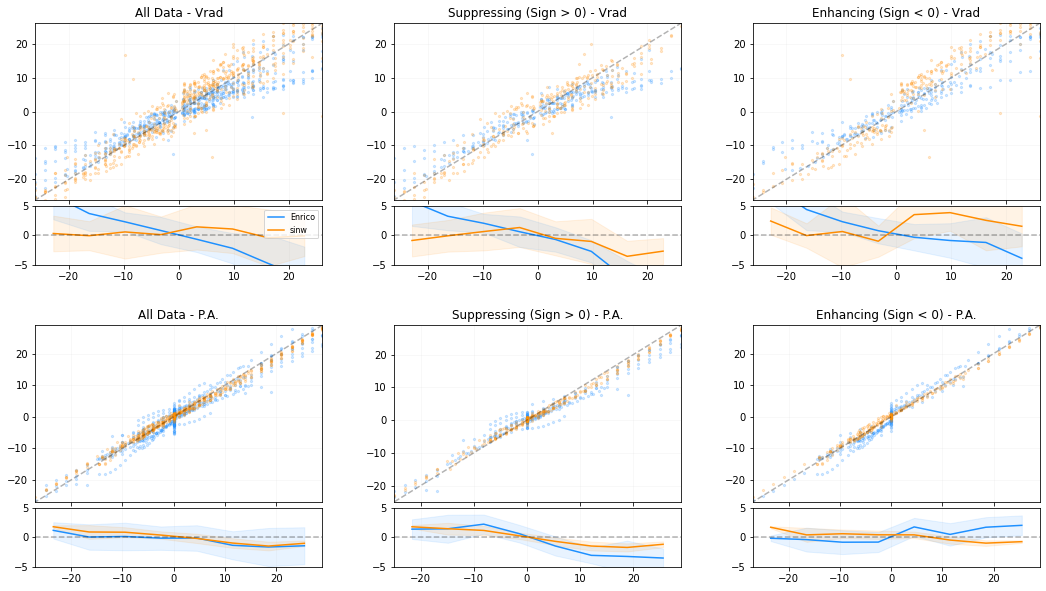

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. 正则匹配与符号计算
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None: return 0
    return 1 if pa_k * vr_k > 0 else -1

def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        pa_k = float(m.group("pa_k")) if m.group("pa_k") else None
        vr_k = float(m.group("vr_k")) if m.group("vr_k") else None
        
        # 构建路径
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t, df_r1, df_r2 = pd.read_csv(tf_path, r"\s+"), pd.read_csv(r1_path, r"\s+"), pd.read_csv(r2_path, r"\s+")
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                    "sign":      compute_sign(pa_k, vr_k)
                })
                # 排除 Vrad=0
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                if not combined.empty: all_dfs.append(combined)
            except: continue
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. 统计与绘图
# ==========================================
def bin_stats(x, y, nbins=8):
    res = y - x
    bin_edges = np.linspace(x.min(), x.max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    means = [res[idx == i].mean() if (idx == i).any() else np.nan for i in range(nbins)]
    stds = [res[idx == i].std() if (idx == i).any() else np.nan for i in range(nbins)]
    return centers, np.array(means), np.array(stds)

def plot_sub_panel(ax_sc, ax_rs, df, t_col, r1_col, r2_col, label, is_pa=False):
    tx, r1y, r2y = df[t_col].values, df[r1_col].values, df[r2_col].values
    if is_pa: tx, r1y, r2y = tx-120, r1y-120, r2y-120
    
    # Scatter
    ax_sc.scatter(tx, r1y, s=5, color='dodgerblue', alpha=0.2)
    ax_sc.scatter(tx, r2y, s=5, color='darkorange', alpha=0.2)
    
    # Stats Line
    for y_data, color, lab in [(r1y, 'dodgerblue', 'Enrico'), (r2y, 'darkorange', 'sinw')]:
        c, m, s = bin_stats(tx, y_data)
        ax_rs.plot(c, m, color=color, lw=1.5, label=lab)
        ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.1)

    ax_sc.plot([-30, 30], [-30, 30], 'k--', alpha=0.3)
    ax_sc.set_xlim(tx.min(), tx.max()); ax_sc.set_ylim(tx.min(), tx.max())
    ax_rs.axhline(0, color='k', ls='--', alpha=0.3)
    ax_rs.set_ylim(-5, 5)
    ax_sc.grid(True, alpha=0.1); ax_rs.grid(True, alpha=0.1)

def main():
    df_all = load_data()
    if df_all.empty: return
    
    df_supp = df_all[df_all["sign"] > 0]
    df_enh = df_all[df_all["sign"] < 0]
    
    fig = plt.figure(figsize=(18, 10))
    outer_gs = gridspec.GridSpec(2, 3, hspace=0.25, wspace=0.25)
    
    titles = ["All Data", "Suppressing (Sign > 0)", "Enhancing (Sign < 0)"]
    datasets = [df_all, df_supp, df_enh]
    
    for i in range(3):
        # Row 0: VRAD
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, i], height_ratios=[3, 1], hspace=0.05)
        ax_v_sc = fig.add_subplot(inner_v[0])
        ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
        plot_sub_panel(ax_v_sc, ax_v_rs, datasets[i], "True_VRAD", "R1_VRAD", "R2_VRAD", "Vrad")
        ax_v_sc.set_title(f"{titles[i]} - Vrad")
        if i == 0: ax_v_rs.legend(fontsize=8)

        # Row 1: PA
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1, i], height_ratios=[3, 1], hspace=0.05)
        ax_p_sc = fig.add_subplot(inner_p[0])
        ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
        plot_sub_panel(ax_p_sc, ax_p_rs, datasets[i], "True_PA", "R1_PA", "R2_PA", "PA", is_pa=True)
        ax_p_sc.set_title(f"{titles[i]} - P.A.")

    plt.savefig("suppress_enhance_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()

Plot saved as: comparison_by_inclination.png


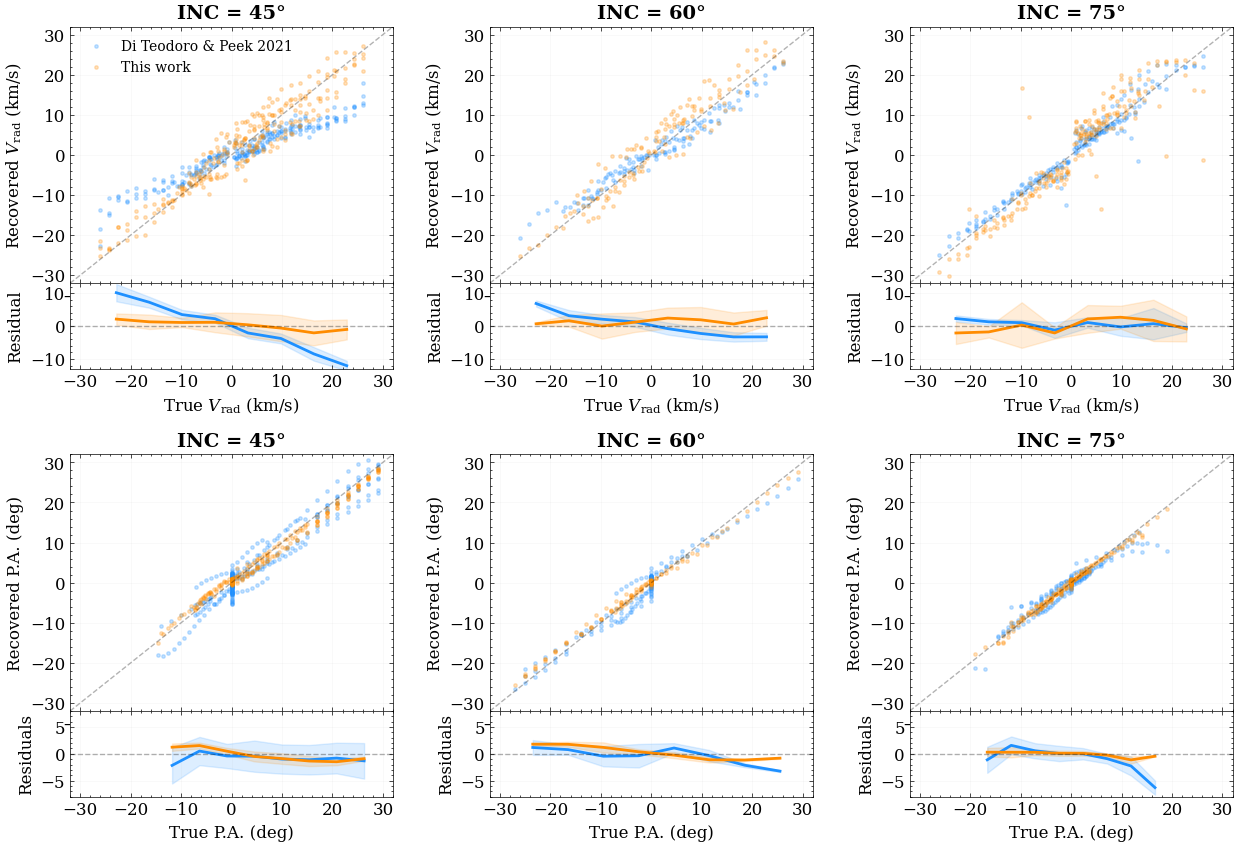

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

# In your plot_inc_panel function, after defining ax_sc or ax_rs:


plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ==========================================
# 1. 路径配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# ==========================================
# 2. 数据加载 (包含 INC 提取)
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def load_data_by_inc():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        inc_val = int(m.group("inc"))
        
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            # print(tf_path,r1_path,r2_path)
            # try:
            df_t, df_r1, df_r2 = pd.read_csv(tf_path, sep=r"\s+"), pd.read_csv(r1_path,sep= r"\s+"), pd.read_csv(r2_path,sep= r"\s+")
            n = min(len(df_t), len(df_r1), len(df_r2))
            
            combined = pd.DataFrame({
                "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                "True_PA":   df_t["P.A.(deg)"][:n].values,
                "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                "INC":       inc_val
            })
            # 排除 Vrad=0
            combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
            if not combined.empty: all_dfs.append(combined)
            # except: continue
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. 绘图函数
# ==========================================
def bin_stats(x, y, nbins=8):
    res = y - x
    valid = ~np.isnan(x) & ~np.isnan(y)
    if not valid.any(): return np.array([]), np.array([]), np.array([])
    
    bin_edges = np.linspace(x[valid].min(), x[valid].max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    means = [res[idx == i].mean() if (idx == i).any() else np.nan for i in range(nbins)]
    stds = [res[idx == i].std() if (idx == i).any() else np.nan for i in range(nbins)]
    return centers, np.array(means), np.array(stds)

def plot_inc_panel(ax_sc, ax_rs, df, t_col, r1_col, r2_col, is_pa=False):
    tx, r1y, r2y = df[t_col].values, df[r1_col].values, df[r2_col].values
    if is_pa: tx, r1y, r2y = tx-120, r1y-120, r2y-120
    
    # Scatter points
    ax_sc.scatter(tx, r1y, s=6, color='dodgerblue', alpha=0.25,rasterized=True, label='Di Teodoro & Peek 2021' if not is_pa else "")
    ax_sc.scatter(tx, r2y, s=6, color='darkorange', alpha=0.25, rasterized=True,label='This work' if not is_pa else "")
    
    # Trend lines
    for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
        c, m, s = bin_stats(tx, y_data)
        if len(c) > 0:
            ax_rs.plot(c, m, color=color, lw=2)
            ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.15)

    # Styling
    min_val, max_val = tx.min(), tx.max()
    ax_sc.plot([-32, 32], [-32, 32], 'k--', alpha=0.3)
    ax_sc.set_xlim(-32, 32); ax_sc.set_ylim(-32, 32)
    ax_rs.axhline(0, color='k', ls='--', alpha=0.3)
    if is_pa==True:
        ax_rs.set_ylim(-8, 8)
    else:
        ax_rs.set_ylim(-13, 13)
    ax_sc.grid(True, alpha=0.1); ax_rs.grid(True, alpha=0.1)

def main():
    df_all = load_data_by_inc()
    if df_all.empty:
        print("No data loaded. Check paths and regex.")
        return
    
    unique_incs = sorted(df_all["INC"].unique())
    n_incs = len(unique_incs)
    
    fig = plt.figure(figsize=(5 * n_incs, 10))
    # 2 rows (Vrad, PA), n_incs columns
    outer_gs = gridspec.GridSpec(2, n_incs, hspace=0.25, wspace=0.3)
    
    for j, inc in enumerate(unique_incs):
        df_sub = df_all[df_all["INC"] == inc]
        
        # --- Top Row: VRAD ---
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, j], height_ratios=[3, 1],hspace=0)
        ax_v_sc = fig.add_subplot(inner_v[0])
        ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
        plot_inc_panel(ax_v_sc, ax_v_rs, df_sub, "True_VRAD", "R1_VRAD", "R2_VRAD")
        ax_v_sc.set_title(f"INC = {inc}°", fontsize=14, fontweight='bold')
        if inc==45:
            ax_v_sc.legend(loc='upper left', fontsize=10)
        ax_v_sc.set_ylabel(r"Recovered $V_{\rm rad}$ (km/s)", fontsize=12)
        ax_v_rs.set_ylabel("Residual", fontsize=12)
        ax_v_rs.set_xlabel(r"True $V_{\rm rad}$ (km/s)", fontsize=12)
        # --- Bottom Row: PA ---
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1, j], height_ratios=[3, 1],hspace=0)
        ax_p_sc = fig.add_subplot(inner_p[0])
        ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
        plot_inc_panel(ax_p_sc, ax_p_rs, df_sub, "True_PA", "R1_PA", "R2_PA", is_pa=True)
        ax_p_sc.set_title(f"INC = {inc}°", fontsize=14, fontweight='bold')
        
        ax_p_sc.set_ylabel("Recovered P.A. (deg)", fontsize=12)
        ax_p_rs.set_ylabel("Residuals", fontsize=12)
        ax_p_rs.set_xlabel("True P.A. (deg)", fontsize=12)
        ax_p_rs.xaxis.set_major_locator(ticker.MultipleLocator(10))
        ax_v_rs.xaxis.set_major_locator(ticker.MultipleLocator(10))
    plt.savefig("comparison_by_inclination_DI.pdf", dpi=300, bbox_inches='tight')
    print("Plot saved as: comparison_by_inclination.png")
    plt.show()

if __name__ == "__main__":
    main()

# DATASERVER3/para_Barolo/test_more_model/model1123_processed_60/Archive/output/06/rings_final2.txt
# DATASERVER3/para_Barolo/test_more_model/model1123/ring_v200_R50_PAfixed_VR0_INC75/second_step_check_sinw

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径配置 (保持不变)
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

# ==========================================
# 2. 数据加载与误差分析
# ==========================================
def load_and_analyze():
    all_dfs = []
    galaxy_errors = [] # 存储每个星系的统计误差
    
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t  = pd.read_csv(tf_path, delimiter=r"\s+")
                df_r1 = pd.read_csv(r1_path, delimiter=r"\s+")
                df_r2 = pd.read_csv(r2_path, delimiter=r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                # 提取 VRAD 数据 (过滤 True_VRAD != 0)
                t_vrad  = df_t["VRAD(km/s)"][:n].values
                r1_vrad = df_r1["VRAD(km/s)"][:n].values
                r2_vrad = df_r2["VRAD(km/s)"][:n].values
                
                mask = t_vrad != 0
                if not np.any(mask): continue
                
                # 计算该星系的平均绝对误差 (MAE)
                # a1: Result 1 与标准的差距
                # a2: Result 2 与标准的差距
                a1 = np.mean(np.abs(r1_vrad[mask] - t_vrad[mask]))
                a2 = np.mean(np.abs(r2_vrad[mask] - t_vrad[mask]))
                
                galaxy_errors.append({
                    "Galaxy_ID": fid,
                    "Filename": fname,
                    "a1_err": a1,
                    "a2_err": a2,
                    "diff": np.abs(a2 - a1)
                })

                # 合并数据用于绘图
                combined = pd.DataFrame({
                    "True_VRAD": t_vrad[mask],
                    "R1_VRAD": r1_vrad[mask],
                    "R2_VRAD": r2_vrad[mask],
                    "True_PA": df_t["P.A.(deg)"][:n].values[mask],
                    "R1_PA": df_r1["P.A.(deg)"][:n].values[mask],
                    "R2_PA": df_r2["P.A.(deg)"][:n].values[mask],
                })
                all_dfs.append(combined)
                
            except Exception as e:
                print(f"Error processing {fid}: {e}")
                
    full_data = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
    error_df = pd.DataFrame(galaxy_errors)
    
    return full_data, error_df

# ==========================================
# 3. 统计输出与绘图 (绘图部分基本保持不变)
# ==========================================
# ... bin_stats 和 plot_comparison 函数保持你原来的即可 ...

if __name__ == "__main__":
    data, error_stats = load_and_analyze()
    
    if not error_stats.empty:
        print("\n" + "="*80)
        print(f"{'RANK':<5} | {'GALAXY ID':<10} | {'a1 (Result1)':<15} | {'a2 (Result2)':<15} | {'|a2 - a1|':<15}")
        print("-" * 80)
        
        # 按照 |a2 - a1| 降序排列，取前五个
        top_5_diff = error_stats.sort_values(by="diff", ascending=False).head(5)
        
        for i, (idx, row) in enumerate(top_5_diff.iterrows(), 1):
            print(f"{i:<5} | {row['Galaxy_ID']:<10} | {row['a1_err']:<15.4f} | {row['a2_err']:<15.4f} | {row['diff']:<15.4f}")
        
        print("="*80)
        print(f"Total processed galaxies: {len(error_stats)}")
        
        # 调用原来的绘图函数
        # plot_comparison(data) 
    else:
        print("No matching data found.")


RANK  | GALAXY ID  | a1 (Result1)    | a2 (Result2)    | |a2 - a1|      
--------------------------------------------------------------------------------
1     | 32         | 2.5110          | 8.6320          | 6.1210         
2     | 33         | 0.4233          | 4.8400          | 4.4167         
3     | 41         | 0.5602          | 4.8543          | 4.2941         
4     | 37         | 0.1846          | 4.4751          | 4.2906         
5     | 23         | 5.5114          | 1.4611          | 4.0503         
Total processed galaxies: 56


/tmp/ipykernel_3145844/3151148638.py:110: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only
  df_all = load_integrated_data()


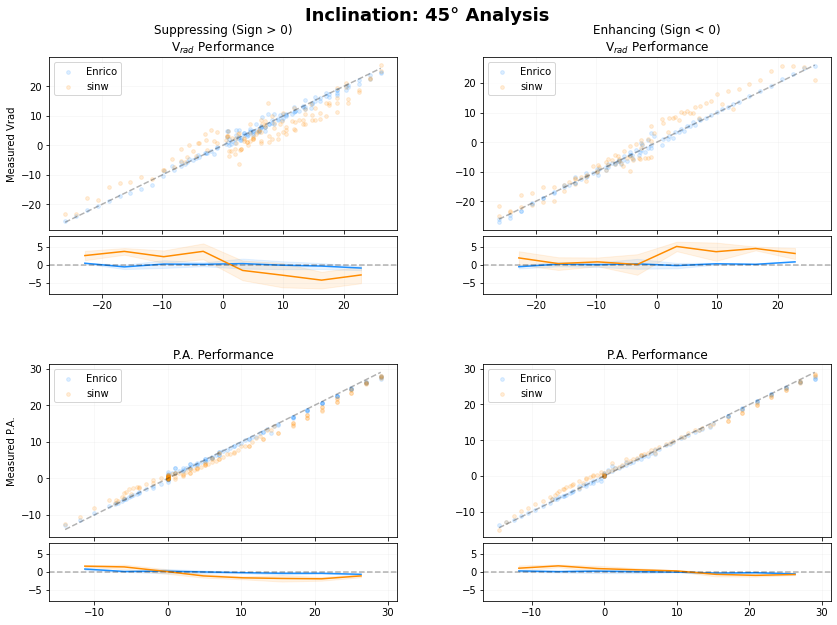

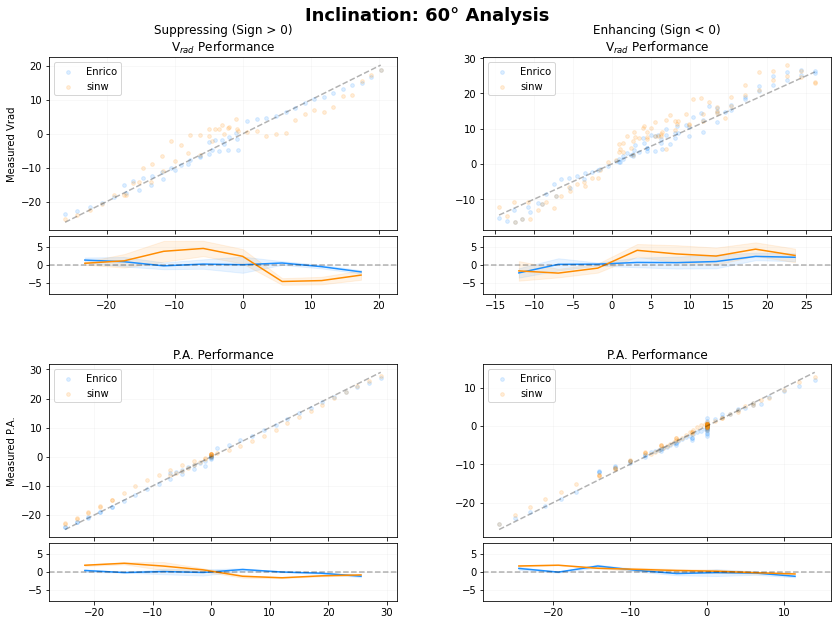

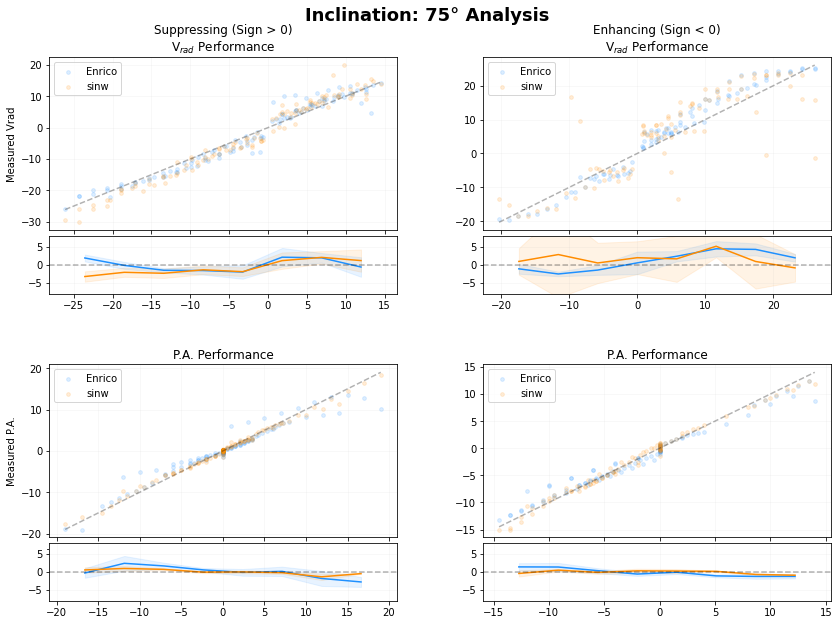

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. Path Configuration
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. Data Loading & Categorization
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None: return 0
    return 1 if pa_k * vr_k > 0 else -1

def load_integrated_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        inc_val = int(m.group("inc"))
        pa_k = float(m.group("pa_k")) if m.group("pa_k") else None
        vr_k = float(m.group("vr_k")) if m.group("vr_k") else None
        
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t = pd.read_csv(tf_path, r"\s+")
                df_r1 = pd.read_csv(r1_path, r"\s+")
                df_r2 = pd.read_csv(r2_path, r"\s+")
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                    "INC":       inc_val,
                    "sign":      compute_sign(pa_k, vr_k)
                })
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                if not combined.empty: all_dfs.append(combined)
            except: continue
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. Plotting Engine
# ==========================================
def bin_stats(x, y, nbins=8):
    res = y - x
    if len(x) < nbins: return np.array([]), np.array([]), np.array([])
    bin_edges = np.linspace(x.min(), x.max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    means = [res[idx == i].mean() if (idx == i).any() else np.nan for i in range(nbins)]
    stds = [res[idx == i].std() if (idx == i).any() else np.nan for i in range(nbins)]
    return centers, np.array(means), np.array(stds)

def plot_panel(ax_sc, ax_rs, df, t_col, r1_col, r2_col, is_pa=False):
    if df.empty: return
    tx, r1y, r2y = df[t_col].values, df[r1_col].values, df[r2_col].values
    if is_pa: tx, r1y, r2y = tx-120, r1y-120, r2y-120
    
    # Scatter
    ax_sc.scatter(tx, r1y, s=14, color='dodgerblue', alpha=0.15,label='Enrico' )
    ax_sc.scatter(tx, r2y, s=14, color='darkorange', alpha=0.15,label='sinw' )
    
    # Stats
    for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
        c, m, s = bin_stats(tx, y_data)
        if len(c) > 0:
            ax_rs.plot(c, m, color=color, lw=1.5)
            ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.1)

    ax_sc.plot([tx.min(), tx.max()], [tx.min(), tx.max()], 'k--', alpha=0.3)
    ax_rs.axhline(0, color='k', ls='--', alpha=0.3)
    ax_rs.set_ylim(-8, 8)
    ax_sc.grid(True, alpha=0.1); ax_rs.grid(True, alpha=0.1)
    ax_sc.legend()
def main():
    df_all = load_integrated_data()
    if df_all.empty:
        print("No data found."); return
    
    incs = sorted(df_all["INC"].unique())
    # We will create one figure per Inclination to keep it readable
    for inc in incs:
        df_inc = df_all[df_all["INC"] == inc]
        
        # Split into Suppressing (Sign > 0) and Enhancing (Sign < 0)
        df_supp = df_inc[df_inc["sign"] > 0]
        df_enh = df_inc[df_inc["sign"] < 0]
        
        fig = plt.figure(figsize=(14, 10))
        fig.suptitle(f"Inclination: {inc}° Analysis", fontsize=18, fontweight='bold', y=0.95)
        
        # Grid: 2 rows (Vrad, PA) x 2 columns (Suppressing, Enhancing)
        outer_gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)
        
        modes = [("Suppressing (Sign > 0)", df_supp), ("Enhancing (Sign < 0)", df_enh)]
        
        for col_idx, (title, data) in enumerate(modes):
            # Vrad Row
            inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, col_idx], height_ratios=[3, 1], hspace=0.05)
            ax_v_sc = fig.add_subplot(inner_v[0]); ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
            plot_panel(ax_v_sc, ax_v_rs, data, "True_VRAD", "R1_VRAD", "R2_VRAD")
            ax_v_sc.set_title(f"{title}\nV$_{{rad}}$ Performance")
            
            # PA Row
            inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1, col_idx], height_ratios=[3, 1], hspace=0.05)
            ax_p_sc = fig.add_subplot(inner_p[0]); ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
            plot_panel(ax_p_sc, ax_p_rs, data, "True_PA", "R1_PA", "R2_PA", is_pa=True)
            ax_p_sc.set_title(f"P.A. Performance")
            
            if col_idx == 0:
                ax_v_sc.set_ylabel("Measured Vrad")
                ax_p_sc.set_ylabel("Measured P.A.")
            
        #plt.savefig(f"analysis_inc_{inc}.png", dpi=300, bbox_inches='tight')
        #print(f"Saved plot for INC {inc}")
        #plt.close()

if __name__ == "__main__":
    main()

In [4]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. Path Configuration
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/"
# Added Third Method Path



# ==========================================
# 2. Regex and Helpers
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None: return 0
    return 1 if pa_k * vr_k > 0 else -1

def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        pa_k = float(m.group("pa_k")) if m.group("pa_k") else None
        vr_k = float(m.group("vr_k")) if m.group("vr_k") else None
        
        # Paths for R1, R2, and R3
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        # Update this path logic based on how Method 3 is structured
        r3_path = os.path.join(RES2_BASE, folder_name_r2,"second_step_noweight","rings_final2.txt") 
        
        
        if all(os.path.exists(p) for p in [r1_path, r2_path, r3_path]):
            try:
                df_t = pd.read_csv(tf_path, r"\s+")
                df_r1 = pd.read_csv(r1_path, r"\s+")
                df_r2 = pd.read_csv(r2_path, r"\s+")
                df_r3 = pd.read_csv(r3_path, r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2), len(df_r3))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "R3_VRAD":   df_r3["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                    "R3_PA":     df_r3["P.A.(deg)"][:n].values,
                    "sign":      compute_sign(pa_k, vr_k)
                })
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                if not combined.empty: all_dfs.append(combined)
            except: continue
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. Statistics & Plotting
# ==========================================
def bin_stats(x, y, nbins=8):
    res = y - x
    bin_edges = np.linspace(x.min(), x.max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    means = [res[idx == i].mean() if (idx == i).any() else np.nan for i in range(nbins)]
    stds = [res[idx == i].std() if (idx == i).any() else np.nan for i in range(nbins)]
    return centers, np.array(means), np.array(stds)

def plot_sub_panel(ax_sc, ax_rs, df, t_col, r1_col, r2_col, r3_col, is_pa=False):
    tx = df[t_col].values
    y_cols = [(r1_col, 'dodgerblue', 'Enrico'), 
              (r2_col, 'darkorange', 'sinw'),
              (r3_col, 'forestgreen', 'noweight')] # Added green for Method 3
    
    if is_pa: tx = tx - 120 # Adjusting center for PA
    
    for col, color, lab in y_cols:
        y_val = df[col].values
        if is_pa: y_val = y_val - 120
        
        # Scatter with very low alpha to handle 3 layers
        ax_sc.scatter(tx, y_val, s=4, color=color, alpha=0.1)
        
        # Stats Line
        c, m, s = bin_stats(tx, y_val)
        ax_rs.plot(c, m, color=color, lw=1.8, label=lab)
        ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.1)

    # Reference lines
    ax_sc.plot([tx.min(), tx.max()], [tx.min(), tx.max()], 'k--', alpha=0.3)
    ax_sc.set_xlim(tx.min(), tx.max())
    ax_sc.set_ylim(tx.min(), tx.max())
    
    ax_rs.axhline(0, color='k', ls='--', alpha=0.3)
    ax_rs.set_ylim(-5, 5)
    ax_sc.grid(True, alpha=0.1); ax_rs.grid(True, alpha=0.1)

def main():
    df_all = load_data()
    if df_all.empty: 
        print("No data found. Check your paths.")
        return
    
    df_supp = df_all[df_all["sign"] > 0]
    df_enh = df_all[df_all["sign"] < 0]
    
    fig = plt.figure(figsize=(20, 11))
    outer_gs = gridspec.GridSpec(2, 3, hspace=0.25, wspace=0.25)
    
    titles = ["All Data", "Suppressing (Sign > 0)", "Enhancing (Sign < 0)"]
    datasets = [df_all, df_supp, df_enh]
    
    for i in range(3):
        # Row 0: VRAD
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, i], height_ratios=[3, 1], hspace=0.05)
        ax_v_sc = fig.add_subplot(inner_v[0])
        ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
        plot_sub_panel(ax_v_sc, ax_v_rs, datasets[i], "True_VRAD", "R1_VRAD", "R2_VRAD", "R3_VRAD")
        ax_v_sc.set_title(f"{titles[i]} - Vrad")
        if i == 0: ax_v_rs.legend(fontsize=9, loc='upper left')

        # Row 1: PA
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1, i], height_ratios=[3, 1], hspace=0.05)
        ax_p_sc = fig.add_subplot(inner_p[0])
        ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
        plot_sub_panel(ax_p_sc, ax_p_rs, datasets[i], "True_PA", "R1_PA", "R2_PA", "R3_PA", is_pa=True)
        ax_p_sc.set_title(f"{titles[i]} - P.A.")

    #plt.savefig("three_method_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()

No data found. Check your paths.


In [6]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. Path Configuration
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/"

# ==========================================
# 2. Regex and Helpers
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)


def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None: return 0
    return 1 if pa_k * vr_k > 0 else -1

def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        pa_k = float(m.group("pa_k")) if m.group("pa_k") else None
        vr_k = float(m.group("vr_k")) if m.group("vr_k") else None
        
        # Paths for R1, R2, R3, and R4
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        r3_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_noweight", "rings_final2.txt") 
        r4_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sin2w", "rings_final2.txt") # New Path
        
        # Check if all four files exist
        paths = [r1_path, r2_path, r3_path, r4_path]
        if all(os.path.exists(p) for p in paths):
            try:
                df_t = pd.read_csv(tf_path, r"\s+")
                df_r1 = pd.read_csv(r1_path, r"\s+")
                df_r2 = pd.read_csv(r2_path, r"\s+")
                df_r3 = pd.read_csv(r3_path, r"\s+")
                df_r4 = pd.read_csv(r4_path, r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2), len(df_r3), len(df_r4))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "R3_VRAD":   df_r3["VRAD(km/s)"][:n].values,
                    "R4_VRAD":   df_r4["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":     df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":     df_r2["P.A.(deg)"][:n].values,
                    "R3_PA":     df_r3["P.A.(deg)"][:n].values,
                    "R4_PA":     df_r4["P.A.(deg)"][:n].values,
                    "sign":      compute_sign(pa_k, vr_k)
                })
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                if not combined.empty: all_dfs.append(combined)
            except Exception as e:
                continue
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 3. Statistics & Plotting
# ==========================================
def bin_stats(x, y, nbins=8):
    res = y - x
    bin_edges = np.linspace(x.min(), x.max(), nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    means = [res[idx == i].mean() if (idx == i).any() else np.nan for i in range(nbins)]
    stds = [res[idx == i].std() if (idx == i).any() else np.nan for i in range(nbins)]
    return centers, np.array(means), np.array(stds)

def plot_sub_panel(ax_sc, ax_rs, df, t_col, r1_col, r2_col, r3_col, r4_col, is_pa=False):
    tx = df[t_col].values
    y_cols = [
        (r1_col, 'dodgerblue', 'Enrico'), 
        (r2_col, 'darkorange', 'sinw'),
        (r3_col, 'forestgreen', 'noweight'),
        (r4_col, 'rebeccapurple', 'sin2w') # Added sin2w
    ]
    
    if is_pa: tx = tx - 120 
    
    for col, color, lab in y_cols:
        y_val = df[col].values
        if is_pa: y_val = y_val - 120
        
        # Scatter with lower alpha for 4 layers
        ax_sc.scatter(tx, y_val, s=3, color=color, alpha=0.08)
        
        # Stats Line
        c, m, s = bin_stats(tx, y_val)
        ax_rs.plot(c, m, color=color, lw=1.8, label=lab)
        ax_rs.fill_between(c, m-s, m+s, color=color, alpha=0.1)

    # Reference lines
    ax_sc.plot([tx.min(), tx.max()], [tx.min(), tx.max()], 'k--', alpha=0.3)
    ax_sc.set_xlim(tx.min(), tx.max())
    ax_sc.set_ylim(tx.min(), tx.max())
    
    ax_rs.axhline(0, color='k', ls='--', alpha=0.3)
    ax_rs.set_ylim(-5, 5)
    ax_sc.grid(True, alpha=0.1); ax_rs.grid(True, alpha=0.1)

def main():
    df_all = load_data()
    
    if df_all.empty: 
        print("No data found. Check your paths.")
        return
    
    df_supp = df_all[df_all["sign"] > 0]
    df_enh = df_all[df_all["sign"] < 0]
    
    fig = plt.figure(figsize=(22, 11)) # Slightly wider for 4 methods
    outer_gs = gridspec.GridSpec(2, 3, hspace=0.25, wspace=0.25)
    
    titles = ["All Data", "Suppressing (Sign > 0)", "Enhancing (Sign < 0)"]
    datasets = [df_all, df_supp, df_enh]
    
    for i in range(3):
        # Row 0: VRAD
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, i], height_ratios=[3, 1], hspace=0.05)
        ax_v_sc = fig.add_subplot(inner_v[0])
        ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
        plot_sub_panel(ax_v_sc, ax_v_rs, datasets[i], "True_VRAD", "R1_VRAD", "R2_VRAD", "R3_VRAD", "R4_VRAD")
        ax_v_sc.set_title(f"{titles[i]} - Vrad")
        if i == 0: ax_v_rs.legend(fontsize=8, loc='upper left', ncol=2) # Multi-column legend

        # Row 1: PA
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[1, i], height_ratios=[3, 1], hspace=0.05)
        ax_p_sc = fig.add_subplot(inner_p[0])
        ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
        plot_sub_panel(ax_p_sc, ax_p_rs, datasets[i], "True_PA", "R1_PA", "R2_PA", "R3_PA", "R4_PA", is_pa=True)
        ax_p_sc.set_title(f"{titles[i]} - P.A.")

    #plt.savefig("four_method_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()

No data found. Check your paths.


Total valid data points: 601

Parameter    | Method          |   Median |     16th |     84th
-----------------------------------------------------------------
Vrad (km/s)  | uniform weight  |    0.453 |   -3.056 |    4.026
Vrad (km/s)  | $\mathrm{sin\theta}$ |    0.521 |   -2.866 |    3.772
Vrad (km/s)  | $\mathrm{sin\theta^2}$ |    0.270 |   -2.860 |    4.025
-----------------------------------------------------------------
P.A. (deg)   | uniform weight  |    0.105 |   -0.803 |    0.810
P.A. (deg)   | $\mathrm{sin\theta}$ |    0.153 |   -0.879 |    0.834
P.A. (deg)   | $\mathrm{sin\theta^2}$ |    0.148 |   -0.953 |    0.918
-----------------------------------------------------------------


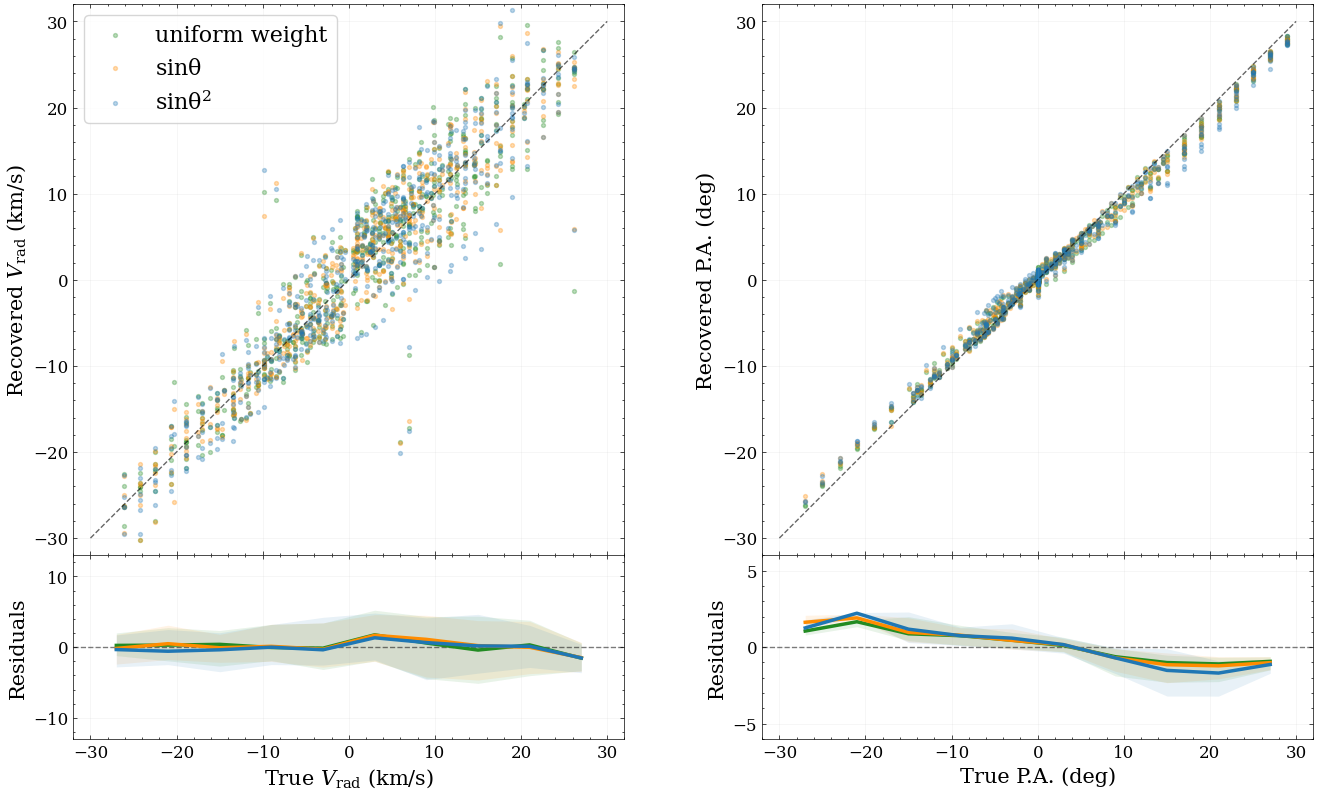

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ==========================================
# 1. Path Configuration
# ==========================================
# 真实值目录
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
# 结果根目录
RES_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/"

# 定义要比较的三个方法及其对应的子文件夹名
METHODS = {
    "uniform weight": {"dir": "second_step_noweight", "color": "forestgreen"},
    r"$\mathrm{sin\theta}$":     {"dir": "second_step_check_sinw", "color": "darkorange"},
    r"$\mathrm{sin\theta^2}$":    {"dir": "second_step_check_sin2w", "color": "tab:blue"}
}

# ==========================================
# 2. Regex & Plot Settings
# ==========================================
pat_fname = re.compile(r"^(?P<id>\d+)_ring_.*")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ==========================================
# 3. Data Loading Logic
# ==========================================
def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        folder_name = fname.replace(f"{fid}_", "").replace(".txt", "")
        
        # 构建三个方法的路径
        paths = {m_name: os.path.join(RES_BASE, folder_name, info["dir"], "rings_final2.txt") 
                 for m_name, info in METHODS.items()}
        
        # 只有当三个文件都存在时才处理
        if all(os.path.exists(p) for p in paths.values()):
            try:
                df_t = pd.read_csv(tf_path, delimiter=r"\s+")
                # 读取各个方法的数据
                dfs_res = {m_name: pd.read_csv(p, delimiter=r"\s+") for m_name, p in paths.items()}
                
                # 取最小长度对齐
                n = min(len(df_t), *[len(d) for d in dfs_res.values()])
                
                data_dict = {
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                }
                
                for m_name, d in dfs_res.items():
                    data_dict[f"{m_name}_VRAD"] = d["VRAD(km/s)"][:n].values
                    data_dict[f"{m_name}_PA"]   = d["P.A.(deg)"][:n].values
                
                combined = pd.DataFrame(data_dict)
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                
                if not combined.empty:
                    all_dfs.append(combined)
            except Exception as e:
                print(f"Error loading {fid}: {e}")
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 4. Statistical Functions
# ==========================================
def bin_stats_robust(x, y, nbins=10):
    res = y - x
    bin_edges = np.linspace(-30, 30, nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    
    med, p16, p84 = [], [], []
    for i in range(nbins):
        mask = (idx == i)
        if mask.any():
            med.append(np.nanpercentile(res[mask], 50))
            p16.append(np.nanpercentile(res[mask], 16))
            p84.append(np.nanpercentile(res[mask], 84))
        else:
            med.extend([np.nan]*3)
            
    return centers, np.array(med), np.array(p16), np.array(p84)

def print_summary_stats(df):
    params = [("Vrad (km/s)", "VRAD"), ("P.A. (deg)", "PA")]
    
    print("\n" + "="*65)
    print(f"{'Parameter':<12} | {'Method':<15} | {'Median':>8} | {'16th':>8} | {'84th':>8}")
    print("-" * 65)
    
    for p_label, p_key in params:
        t_col = f"True_{p_key}"
        for m_name in METHODS.keys():
            res = df[f"{m_name}_{p_key}"] - df[t_col]
            med, p16, p84 = np.nanpercentile(res, [50, 16, 84])
            print(f"{p_label:<12} | {m_name:<15} | {med:8.3f} | {p16:8.3f} | {p84:8.3f}")
        print("-" * 65)

# ==========================================
# 5. Plotting Function
# ==========================================
def plot_comparison(df):
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.0, wspace=0.25)
    
    tasks = [
        (r"$V_{\rm rad}$ (km/s)", "VRAD", 0),
        ("P.A. (deg)",      "PA",   1)
    ]
    
    for label, p_key, col_idx in tasks:
        ax_sc = fig.add_subplot(gs[0, col_idx])
        ax_rs = fig.add_subplot(gs[1, col_idx], sharex=ax_sc)
        
        t_col = f"True_{p_key}"
        tx = df[t_col].values
        if p_key == "PA": tx = tx - 120  # 中心化处理
        
        for m_name, info in METHODS.items():
            y_data = df[f"{m_name}_{p_key}"].values
            if p_key == "PA": y_data = y_data - 120
            
            # 散点图 (较低透明度以应对三层叠加)
            ax_sc.scatter(tx, y_data, s=8, color=info["color"], alpha=0.3, label=m_name,rasterized=True)
            
            # 统计曲线
            c, med, low, high = bin_stats_robust(tx, y_data)
            ax_rs.plot(c, med, color=info["color"], lw=2.5, zorder=5)
            ax_rs.fill_between(c, low, high, color=info["color"], alpha=0.1, lw=0)

        # 样式调整
        ax_sc.set_box_aspect(1)
        ax_rs.set_box_aspect(1/3)
        ax_sc.set_anchor('S')
        ax_rs.set_anchor('N')
        plt.setp(ax_sc.get_xticklabels(), visible=False)

        ax_sc.plot([-30, 30], [-30, 30], 'k--', alpha=0.6)
        ax_sc.set_ylabel(f"Recovered {label}")
        if col_idx == 0: ax_sc.legend(loc='upper left', frameon=True)
            
        ax_rs.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_rs.set_ylabel("Residuals")
        ax_rs.set_xlabel(f"True {label}")
        
        ax_sc.set_xlim(-32, 32); ax_sc.set_ylim(-32, 32)
        ax_rs.set_ylim(-13, 13)
        if p_key == "PA":
            ax_rs.set_ylim(-6, 6)
            ax_rs.set_yticks([-5, 0, 5])
        ax_sc.grid(True, alpha=0.15); ax_rs.grid(True, alpha=0.15)
    plt.savefig("weighting_6.pdf",dpi=300)
    plt.show()

if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid data points: {len(data)}")
        print_summary_stats(data)
        plot_comparison(data)
    else:
        print("Error: No data found. Please verify the folder paths.")

Total valid data points: 595

Parameter    | Method                    |   Median |     16th |     84th
--------------------------------------------------
Vrad (km/s)  | Di Teodoro & Peek 2021    |   -0.048 |   -3.855 |    3.065
Vrad (km/s)  | This Work                 |    0.790 |   -3.053 |    4.445
--------------------------------------------------
P.A. (deg)   | Di Teodoro & Peek 2021    |   -0.398 |   -2.473 |    1.730
P.A. (deg)   | This Work                 |    0.141 |   -0.877 |    0.916
--------------------------------------------------


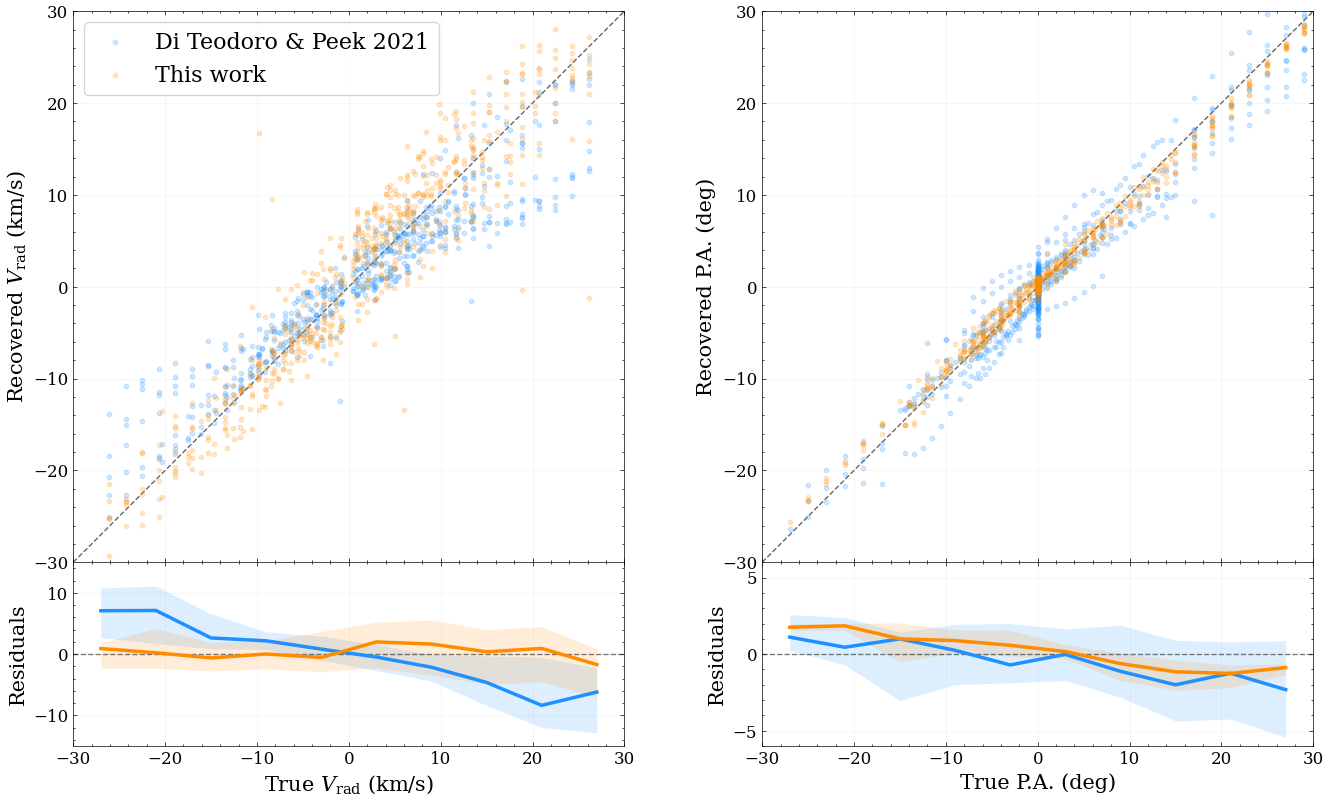

In [7]:
###### !/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ==========================================
# 1. Path Configuration
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/Archive/model1123_processed_60/"
RES1_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123_processed_60/output/"
RES2_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"

# ==========================================
# 2. Regex & Plot Settings
# ==========================================
pat_fname = re.compile(
    r"^(?P<id>\d+)_ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ==========================================
# 3. Data Loading Logic
# ==========================================
def load_data():
    all_dfs = []
    files = sorted(glob.glob(os.path.join(TRUE_DIR, "*.txt")))
    
    for tf_path in files:
        fname = os.path.basename(tf_path)
        m = pat_fname.match(fname)
        if not m: continue
        
        fid = m.group("id")
        r1_path = os.path.join(RES1_BASE, fid, "rings_final2.txt")
        
        folder_name_r2 = fname.replace(f"{fid}_", "").replace(".txt", "")
        r2_path = os.path.join(RES2_BASE, folder_name_r2, "second_step_check_sinw", "rings_final2.txt")
        
        if os.path.exists(r1_path) and os.path.exists(r2_path):
            try:
                df_t  = pd.read_csv(tf_path, delimiter=r"\s+")
                df_r1 = pd.read_csv(r1_path, delimiter=r"\s+")
                df_r2 = pd.read_csv(r2_path, delimiter=r"\s+")
                
                n = min(len(df_t), len(df_r1), len(df_r2))
                
                combined = pd.DataFrame({
                    "True_VRAD": df_t["VRAD(km/s)"][:n].values,
                    "R1_VRAD":   df_r1["VRAD(km/s)"][:n].values,
                    "R2_VRAD":   df_r2["VRAD(km/s)"][:n].values,
                    "True_PA":   df_t["P.A.(deg)"][:n].values,
                    "R1_PA":      df_r1["P.A.(deg)"][:n].values,
                    "R2_PA":      df_r2["P.A.(deg)"][:n].values,
                })
                
                combined = combined[combined["True_VRAD"] != 0].reset_index(drop=True)
                
                if not combined.empty:
                    all_dfs.append(combined)
            except Exception as e:
                print(f"Error loading {fid}: {e}")
                
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

# ==========================================
# 4. Statistical Functions
# ==========================================
def bin_stats_robust(x, y, nbins=10):
    res = y - x
    bin_edges = np.linspace(-30, 30, nbins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.digitize(x, bin_edges) - 1
    
    medians, p16, p84 = [], [], []
    for i in range(nbins):
        mask = (idx == i)
        if mask.any():
            medians.append(np.nanpercentile(res[mask], 50))
            p16.append(np.nanpercentile(res[mask], 16))
            p84.append(np.nanpercentile(res[mask], 84))
        else:
            medians.append(np.nan); p16.append(np.nan); p84.append(np.nan)
            
    return centers, np.array(medians), np.array(p16), np.array(p84)

def print_summary_stats(df):
    """计算并打印全局残差的统计信息"""
    tasks = [
        ("Vrad (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD"),
        ("P.A. (deg)",  "True_PA",   "R1_PA",   "R2_PA")
    ]
    
    print("\n" + "="*50)
    print(f"{'Parameter':<12} | {'Method':<25} | {'Median':>8} | {'16th':>8} | {'84th':>8}")
    print("-" * 50)
    
    for label, t_col, r1_col, r2_col in tasks:
        # 残差 = 恢复值 - 真实值
        res1 = df[r1_col] - df[t_col]
        res2 = df[r2_col] - df[t_col]
        
        for m_name, res in [("Di Teodoro & Peek 2021", res1), ("This Work", res2)]:
            med = np.nanpercentile(res, 50)
            p16 = np.nanpercentile(res, 16)
            p84 = np.nanpercentile(res, 84)
            print(f"{label:<12} | {m_name:<25} | {med:8.3f} | {p16:8.3f} | {p84:8.3f}")
        print("-" * 50)

# ==========================================
# 5. Plotting Function
# ==========================================
def plot_comparison(df):
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.0, wspace=0.25)
    
    tasks = [
        (r"$V_{\rm rad}$ (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD", False, 0),
        ("P.A. (deg)",      "True_PA",   "R1_PA",   "R2_PA",   True,  1)
    ]
    
    for label, t_col, r1_col, r2_col, is_pa, col_idx in tasks:
        ax_sc = fig.add_subplot(gs[0, col_idx])
        ax_rs = fig.add_subplot(gs[1, col_idx], sharex=ax_sc)
        
        tx = df[t_col].values
        r1y = df[r1_col].values
        r2y = df[r2_col].values
        
        if is_pa:
            tx, r1y, r2y = tx - 120, r1y - 120, r2y - 120
        
        ax_sc.scatter(tx, r1y, s=10, color='dodgerblue', alpha=0.2, label='Di Teodoro & Peek 2021', zorder=2,rasterized=True)
        ax_sc.scatter(tx, r2y, s=10, color='darkorange', alpha=0.2, label='This work', zorder=3,rasterized=True)
        
        for y_data, color in [(r1y, 'dodgerblue'), (r2y, 'darkorange')]:
            c, med, low, high = bin_stats_robust(tx, y_data)
            ax_rs.plot(c, med, color=color, lw=2.5, zorder=5)
            ax_rs.fill_between(c, low, high, color=color, alpha=0.15, lw=0)

        ax_sc.set_box_aspect(1)
        ax_rs.set_box_aspect(1/3)
        ax_sc.set_anchor('S')
        ax_rs.set_anchor('N')
        
        plt.setp(ax_sc.get_xticklabels(), visible=False)

        ax_sc.plot([-30, 30], [-30, 30], 'k--', alpha=0.6, zorder=1)
        ax_sc.set_ylabel(f"Recovered {label}")
        
        if not is_pa:
            ax_sc.legend(loc='upper left', frameon=True, fontsize=16)
            
        ax_rs.axhline(0, color='k', linestyle='--', alpha=0.5)
        ax_rs.set_ylabel("Residuals")
        ax_rs.set_xlabel(f"True {label}")
        
        ax_sc.set_xlim(-30, 30)
        ax_sc.set_ylim(-30, 30)
        ax_rs.set_ylim(-15, 15)
        if is_pa:
            ax_rs.set_ylim(-6, 6)
            ax_rs.set_yticks([-5, 0, 5])
        ax_sc.grid(True, alpha=0.15)
        ax_rs.grid(True, alpha=0.15)

    plt.savefig("vrad_pa_comparison_snapped.pdf", dpi=300,bbox_inches='tight')
    plt.show()

# ==========================================
# 6. Execution
# ==========================================
if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid data points: {len(data)}")
        # 1. 打印统计数值
        print_summary_stats(data)
        # 2. 绘图
        plot_comparison(data)
    else:
        print("Error: No data found. Please verify the folder paths.")

Total valid data points: 595

Parameter    | Method                    |   Median |     16th |     84th
----------------------------------------------------------------------
Vrad (km/s)  | Di Teodoro 2021           |   -0.048 |   -3.855 |    3.065
Vrad (km/s)  | This Work                 |    0.833 |   -3.053 |    4.445
----------------------------------------------------------------------
P.A. (deg)   | Di Teodoro 2021           |   -0.398 |   -2.473 |    1.730
P.A. (deg)   | This Work                 |    0.141 |   -0.877 |    0.945
----------------------------------------------------------------------


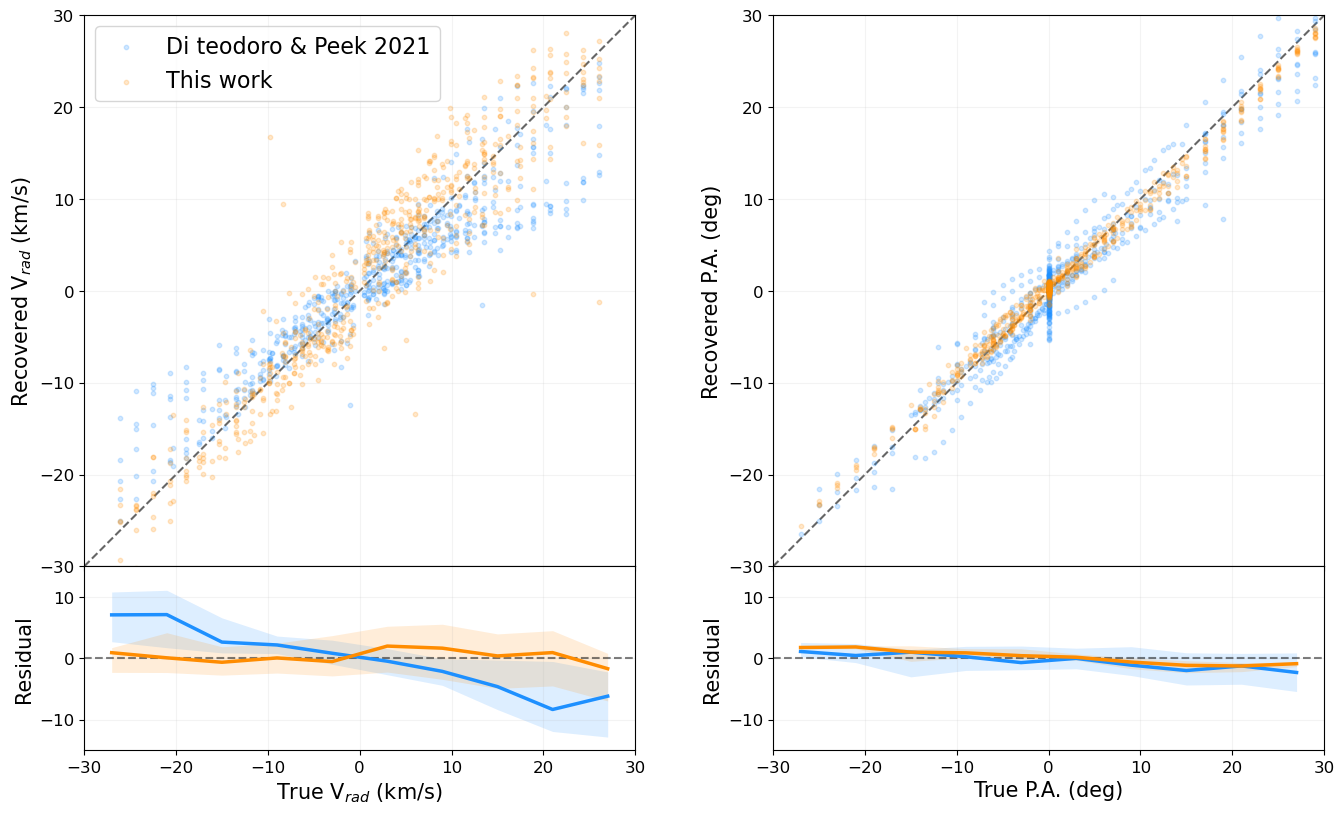

In [21]:
# ... 前面部分代码保持不变 ...

def print_summary_stats(df):
    """
    计算并打印残差 (Recovered - True) 的中位数、16th 和 84th 分位数
    """
    tasks = [
        ("Vrad (km/s)", "True_VRAD", "R1_VRAD", "R2_VRAD"),
        ("P.A. (deg)",  "True_PA",   "R1_PA",   "R2_PA")
    ]
    
    print("\n" + "="*70)
    print(f"{'Parameter':<12} | {'Method':<25} | {'Median':>8} | {'16th':>8} | {'84th':>8}")
    print("-" * 70)
    
    for label, t_col, r1_col, r2_col in tasks:
        # 计算两个模型的残差
        res1 = df[r1_col] - df[t_col]
        res2 = df[r2_col] - df[t_col]
        
        results = [
            ("Di Teodoro 2021", res1),
            ("This Work", res2)
        ]
        
        for name, res in results:
            # 移除 NaN 值后计算分位数
            clean_res = res.dropna()
            med = np.percentile(clean_res, 50)
            p16 = np.percentile(clean_res, 16)
            p84 = np.percentile(clean_res, 84)
            
            print(f"{label:<12} | {name:<25} | {med:8.3f} | {p16:8.3f} | {p84:8.3f}")
        print("-" * 70)

# ==========================================
# 修改后的执行部分
# ==========================================
if __name__ == "__main__":
    data = load_data()
    if not data.empty:
        print(f"Total valid data points: {len(data)}")
        
        # 1. 首先在终端输出统计数值
        print_summary_stats(data)
        
        # 2. 然后生成对比图
        plot_comparison(data)
    else:
        print("Error: No data found. Please verify the folder paths.")